# 07. Phát hiện bất thường bằng Isolation Forest (Isolation Forest Anomaly Detection)

This notebook adds the new Data Mining method: Isolation Forest combined with graph features. K-Means and DBSCAN remain as comparison baselines.


## 1. Import thư viện và thiết lập đường dẫn


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("../datasets")
RESULTS_DIR = Path("../results")
CSV_DIR = RESULTS_DIR / "csv"
MODEL_DIR = RESULTS_DIR / "models"
FIGURE_DIR = RESULTS_DIR / "figures"
PROCESSED_DIR = DATA_DIR / "processed"

FEATURES_WITH_LABEL_PATH = PROCESSED_DIR / "user_features_with_label.csv"
GRAPH_FEATURES_PATH = PROCESSED_DIR / "user_graph_features.csv"
ISOLATION_RESULT_PATH = CSV_DIR / "isolation_forest_results.csv"
ISOLATION_MODEL_PATH = MODEL_DIR / "isolation_forest.pkl"

CSV_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


## 2. Tải các đặc trưng cũ và đặc trưng đồ thị mới


In [2]:
df_users = pd.read_csv(FEATURES_WITH_LABEL_PATH)
graph_features = pd.read_csv(GRAPH_FEATURES_PATH)

print("Old features:", df_users.shape)
print("Graph features:", graph_features.shape)

df = df_users.merge(graph_features, on="user_id", how="left")
graph_cols = ["degree", "degree_centrality", "clustering_coefficient", "interaction_score", "pagerank"]
df[graph_cols] = df[graph_cols].fillna(0)

df.head()


Old features: (50000, 11)
Graph features: (50000, 6)


,user_id,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days,bot_label,degree,degree_centrality,clustering_coefficient,interaction_score,pagerank
0,132131,85,1,2353,0,83,5,0,0,1114,1,11,0.00022,0.145455,0.004391,0.000019
1,289683,55,5,9617,1,77,14,2,1,186,0,10,0.00020,0.177778,0.003366,0.000016
2,779715,6,2,4363,1,61,10,2,1,296,0,9,0.00018,0.166667,0.002577,0.000014
3,696168,54,5,2242,1,49,6,4,1,654,1,13,0.00026,0.102564,0.005319,0.000020
4,704441,26,3,8438,0,29,6,2,1,1142,1,11,0.00022,0.127273,0.004037,0.000017


In [3]:
old_feature_cols = [
    "retweet_count",
    "mention_count",
    "follower_count",
    "verified",
    "tweet_length",
    "username_length",
    "hashtag_count",
    "has_hashtag",
    "account_age_days",
]
feature_cols = old_feature_cols + graph_cols

X = df[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Number of features used for Isolation Forest:", len(feature_cols))
feature_cols


Number of features used for Isolation Forest: 14


['retweet_count',
 'mention_count',
 'follower_count',
 'verified',
 'tweet_length',
 'username_length',
 'hashtag_count',
 'has_hashtag',
 'account_age_days',
 'degree',
 'degree_centrality',
 'clustering_coefficient',
 'interaction_score',
 'pagerank']

## 3. Huấn luyện mô hình Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm. `bot_label`, when available, is used only for evaluation after training.


In [4]:
contamination = 0.05
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

iso_forest.fit(X_scaled)

raw_decision_score = iso_forest.decision_function(X_scaled)
anomaly_label = iso_forest.predict(X_scaled)  # -1 = anomaly, 1 = normal

# Build this step from the available dataset fields.
isolation_score = MinMaxScaler().fit_transform((-raw_decision_score).reshape(-1, 1)).ravel()

print("Anomaly label counts:")
print(pd.Series(anomaly_label).value_counts().sort_index())


Anomaly label counts:
-1     2500
 1    47500
Name: count, dtype: int64


## 4. Xây dựng điểm nghi ngờ dựa trên tập luật đơn giản (Rule-based Suspicious Score)

Each suspicious behavior rule adds one point. The score is normalized to `[0, 1]`.


In [5]:
def robust_ratio(numerator, denominator):
    return numerator / np.maximum(denominator, 1)

suspicious_score = np.zeros(len(df), dtype=float)
rule_flags = pd.DataFrame(index=df.index)

hashtag_ratio = robust_ratio(df["hashtag_count"], df["tweet_length"])
mention_ratio = robust_ratio(df["mention_count"], df["tweet_length"])
retweet_to_follower = robust_ratio(df["retweet_count"], df["follower_count"])

rules = {
    "high_hashtag_count": df["hashtag_count"] >= df["hashtag_count"].quantile(0.95),
    "high_hashtag_ratio": hashtag_ratio >= hashtag_ratio.quantile(0.95),
    "high_mention_count": df["mention_count"] >= df["mention_count"].quantile(0.95),
    "high_retweet_count": df["retweet_count"] >= df["retweet_count"].quantile(0.95),
    "high_retweet_to_follower": retweet_to_follower >= retweet_to_follower.quantile(0.95),
    "low_follower_high_activity": (df["follower_count"] <= df["follower_count"].quantile(0.10)) & (df["retweet_count"] >= df["retweet_count"].quantile(0.75)),
    "high_graph_interaction": df["interaction_score"] >= df["interaction_score"].quantile(0.95),
}

for rule_name, mask in rules.items():
    rule_flags[rule_name] = mask.astype(int)
    suspicious_score += mask.astype(float)

if suspicious_score.max() > 0:
    suspicious_score = suspicious_score / suspicious_score.max()

rule_flags.sum().sort_values(ascending=False)


high_mention_count            8436
high_hashtag_count            8371
high_retweet_count            2924
high_hashtag_ratio            2587
high_retweet_to_follower      2500
high_graph_interaction        2500
low_follower_high_activity    1310
dtype: int64

## 5. Kết hợp Isolation Forest và điểm nghi ngờ


In [6]:
final_anomaly_score = 0.7 * isolation_score + 0.3 * suspicious_score
final_threshold = np.quantile(final_anomaly_score, 1 - contamination)
final_is_anomaly = (final_anomaly_score >= final_threshold).astype(int)
final_anomaly_label = np.where(final_is_anomaly == 1, -1, 1)

result = df.copy()
result["isolation_score"] = isolation_score
result["anomaly_score"] = isolation_score
result["anomaly_label"] = anomaly_label
result["suspicious_score"] = suspicious_score
result["final_anomaly_score"] = final_anomaly_score
result["final_anomaly_label"] = final_anomaly_label
result["is_anomaly"] = final_is_anomaly

for col in rule_flags.columns:
    result[col] = rule_flags[col]

result.head()


,user_id,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days,bot_label,degree,degree_centrality,clustering_coefficient,interaction_score,pagerank,isolation_score,anomaly_score,anomaly_label,suspicious_score,final_anomaly_score,final_anomaly_label,is_anomaly,high_hashtag_count,high_hashtag_ratio,high_mention_count,high_retweet_count,high_retweet_to_follower,low_follower_high_activity,high_graph_interaction
0,132131,85,1,2353,0,83,5,0,0,1114,1,11,0.00022,0.145455,0.004391,0.000019,0.322318,0.322318,1,0.000000,0.225622,1,0,0,0,0,0,0,0,0
1,289683,55,5,9617,1,77,14,2,1,186,0,10,0.00020,0.177778,0.003366,0.000016,0.196504,0.196504,1,0.166667,0.187553,1,0,0,0,1,0,0,0,0
2,779715,6,2,4363,1,61,10,2,1,296,0,9,0.00018,0.166667,0.002577,0.000014,0.075022,0.075022,1,0.000000,0.052515,1,0,0,0,0,0,0,0,0
3,696168,54,5,2242,1,49,6,4,1,654,1,13,0.00026,0.102564,0.005319,0.000020,0.185068,0.185068,1,0.166667,0.179548,1,0,0,0,1,0,0,0,0
4,704441,26,3,8438,0,29,6,2,1,1142,1,11,0.00022,0.127273,0.004037,0.000017,0.228997,0.228997,1,0.000000,0.160298,1,0,0,0,0,0,0,0,0


In [7]:
summary = pd.DataFrame({
    "metric": ["total_users", "isolation_anomaly_users", "final_anomaly_users", "final_anomaly_ratio"],
    "value": [
        len(result),
        int((result["anomaly_label"] == -1).sum()),
        int(result["is_anomaly"].sum()),
        round(result["is_anomaly"].mean() * 100, 2),
    ],
})
summary


,metric,value
0,total_users,50000.0
1,isolation_anomaly_users,2500.0
2,final_anomaly_users,2500.0
3,final_anomaly_ratio,5.0


## 6. Đánh giá hiệu năng khi có nhãn đối chứng


In [8]:
if "bot_label" in result.columns:
    y_true = result["bot_label"].astype(int)
    y_pred = result["is_anomaly"].astype(int)
    eval_metrics = pd.DataFrame({
        "algorithm": ["Isolation Forest"],
        "accuracy": [accuracy_score(y_true, y_pred)],
        "precision": [precision_score(y_true, y_pred, zero_division=0)],
        "recall": [recall_score(y_true, y_pred, zero_division=0)],
        "f1_score": [f1_score(y_true, y_pred, zero_division=0)],
        "anomaly_users": [int(y_pred.sum())],
        "anomaly_ratio": [round(y_pred.mean() * 100, 2)],
    })
    cm = confusion_matrix(y_true, y_pred)
    display(eval_metrics)
    display(pd.DataFrame(cm, index=["Actual normal", "Actual bot"], columns=["Pred normal", "Pred anomaly"]))
else:
    print("No bot_label column, skip supervised evaluation.")


,algorithm,accuracy,precision,recall,f1_score,anomaly_users,anomaly_ratio
0,Isolation Forest,0.49984,0.502,0.050164,0.091213,2500,5.0


,Pred normal,Pred anomaly
Actual normal,23737,1245
Actual bot,23763,1255


## 7. Lưu kết quả và mô hình


In [9]:
result.to_csv(ISOLATION_RESULT_PATH, index=False)
joblib.dump({
    "model": iso_forest,
    "scaler": scaler,
    "feature_cols": feature_cols,
    "contamination": contamination,
    "final_threshold": float(final_threshold),
}, ISOLATION_MODEL_PATH)

print("Saved results:", ISOLATION_RESULT_PATH)
print("Saved model:", ISOLATION_MODEL_PATH)


Saved results: ..\results\csv\isolation_forest_results.csv
Saved model: ..\results\models\isolation_forest.pkl


## 8. Trực quan hóa kết quả


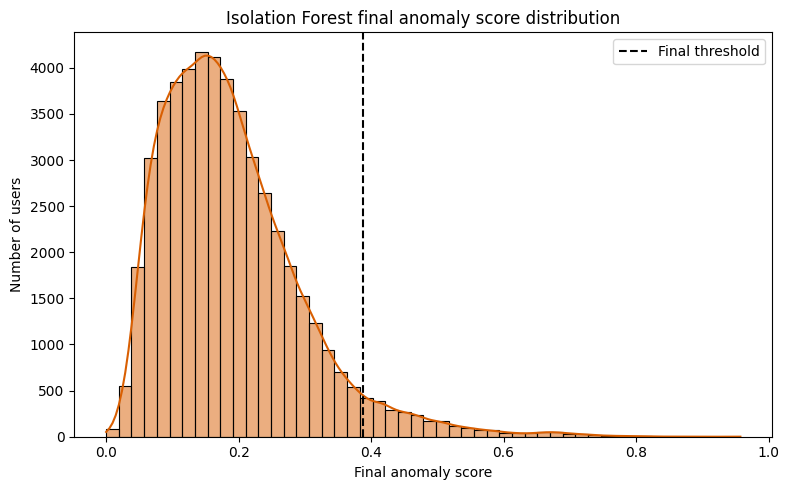

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(result["final_anomaly_score"], bins=50, kde=True, color="#D95F02")
plt.axvline(final_threshold, color="black", linestyle="--", label="Final threshold")
plt.title("Isolation Forest final anomaly score distribution")
plt.xlabel("Final anomaly score")
plt.ylabel("Number of users")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "isolation_forest_anomaly_score_distribution.png", dpi=150)
plt.show()


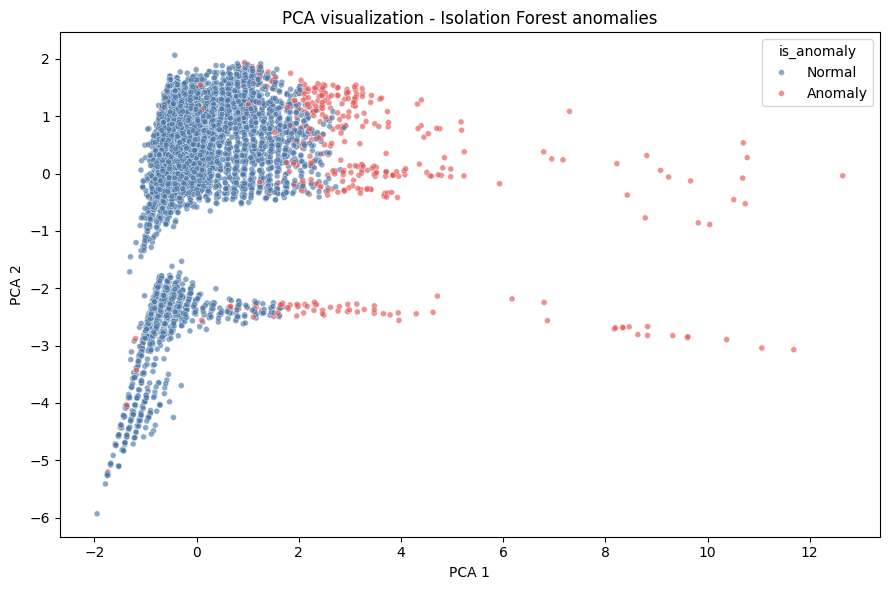

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_points = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "pca_1": pca_points[:, 0],
    "pca_2": pca_points[:, 1],
    "is_anomaly": result["is_anomaly"].map({0: "Normal", 1: "Anomaly"}),
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_df.sample(min(8000, len(plot_df)), random_state=RANDOM_STATE),
    x="pca_1",
    y="pca_2",
    hue="is_anomaly",
    palette={"Normal": "#4C78A8", "Anomaly": "#E45756"},
    alpha=0.65,
    s=18,
)
plt.title("PCA visualization - Isolation Forest anomalies")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pca_isolation_forest_anomaly.png", dpi=150)
plt.show()


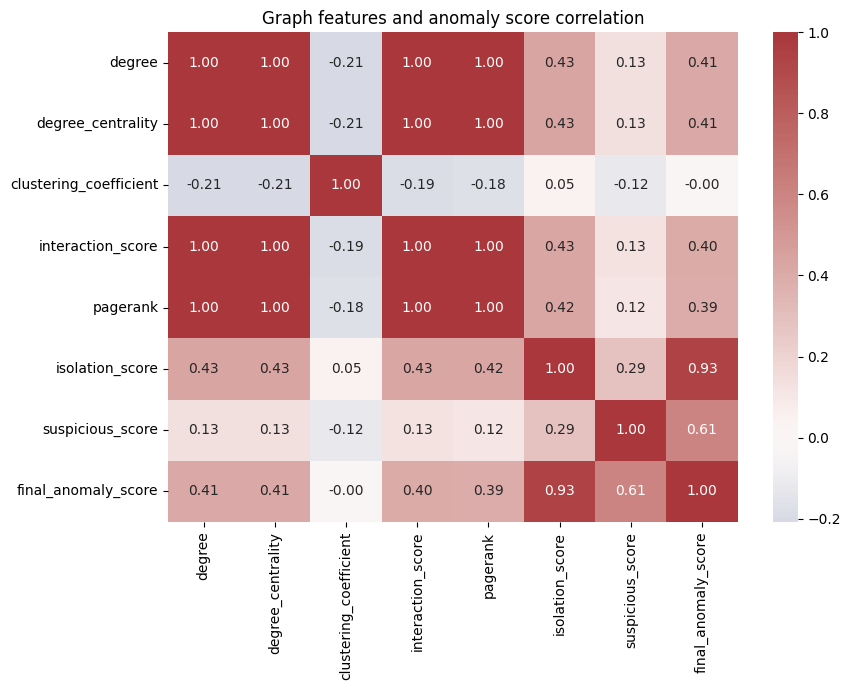

In [12]:
graph_corr_cols = graph_cols + ["isolation_score", "suspicious_score", "final_anomaly_score"]
plt.figure(figsize=(9, 7))
sns.heatmap(result[graph_corr_cols].corr(), annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Graph features and anomaly score correlation")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "isolation_graph_feature_correlation.png", dpi=150)
plt.show()


## 9. Kết luận

The notebook creates Isolation Forest results using old behavior features, graph features, and a simple rule-based suspicious score.
